# 8장 실습 — RT-2: 웹 지식이 손으로 내려오다

**대응 이론** 8장 「RT-2 — 웹 지식이 손으로 내려오다」 · **실행 등급 A** (CPU / Colab 무료 티어, 전체 약 1분)

2부에서 VLA 를 이루는 설계 결정을 하나씩 세웠다. 3부는 그 좌표계 위에 실제 모델을 얹는다. 첫 자리는 RT-2 다.

RT-2 의 주장은 한 문장이다. **로봇 데이터에 없던 것을 웹에서 배워 온다.** 2023년 구글은 콜라 캔 옆에 연예인 사진을 놓고 「테일러 스위프트에게 캔을 옮겨라」라고 시켰다. 로봇 시연 데이터에 그런 장면은 없었다. 성공하려면 탄산음료 상표와 사람 이름과 얼굴을 웹에서 끌어와 그것을 집기·놓기로 바꿔야 한다. 「플래너의 메뉴가 늘었다」와는 다른 주장이다.

이 노트북은 그 주장을 토이 규모에서 **검증 가능한 형태로** 재현한다. 로봇 데모에는 `red` 와 `blue` 만 나오게 하고, 웹 말뭉치에서만 `crimson` 과 `azure` 를 배우게 한 뒤, 데모에 없던 단어로 지시했을 때 팔이 제대로 움직이는지 잰다.

1. 액션을 언어 토큰으로 — 어휘를 하나로 합친다
2. 로봇 데이터와 웹 데이터를 갈라 놓는다
3. 웹에서 단어 뜻을 배운다
4. 데모에 없던 단어로 지시한다
5. co-fine-tuning 은 언제 필요한가

In [1]:
%matplotlib inline
import os, math, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(os.cpu_count() or 2)

RED_C, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"
print("torch", torch.__version__)

torch 2.9.1


## 1. 액션을 언어 토큰으로 — 어휘를 하나로 합친다

RT-2 의 구현상 핵심은 5장에서 이미 다뤘다. 액션을 구간으로 잘라 번호를 매기고, 그 번호를 **언어 모델의 어휘표에 그대로 얹는다.** 그러면 「지시문 + 액션」이 하나의 토큰 열이 되고, 언어 모델은 자기가 늘 하던 일 — 다음 토큰 맞히기 — 을 그대로 한다.

새로 만들 것이 없다는 점이 이 설계의 전부다. 손실 함수도 학습 루프도 사전학습 체크포인트도 손대지 않는다.

In [2]:
WORDS = ["<pad>", "pick", "up", "the", "block", "red", "blue"]
N_BINS = 256
ACTION_TOKENS = [f"<act_{i}>" for i in range(N_BINS)]
UNIFIED = WORDS + ACTION_TOKENS          # 하나의 어휘표
U_STOI = {w: i for i, w in enumerate(UNIFIED)}

def action_to_tokens(a, bins=N_BINS):
    b = ((np.clip(a, -1, 1) + 1) / 2 * (bins - 1)).round().astype(int)
    return [f"<act_{i}>" for i in b]

demo_action = np.array([0.42, -0.31, -0.28, 0.0, 0.0, 0.15, 1.0])
seq = ["pick", "up", "the", "red", "block"] + action_to_tokens(demo_action)
print("어휘 크기:", len(UNIFIED), f"(단어 {len(WORDS)} + 액션 {N_BINS})")
print("\n한 줄로 이어진 학습 표본:")
print(" ", " ".join(seq))
print("\n토큰 번호:", [U_STOI[t] for t in seq])

어휘 크기: 263 (단어 7 + 액션 256)

한 줄로 이어진 학습 표본:
  pick up the red block <act_181> <act_88> <act_92> <act_128> <act_128> <act_147> <act_255>

토큰 번호: [1, 2, 3, 5, 4, 188, 95, 99, 135, 135, 154, 262]


## 2. 로봇 데이터와 웹 데이터를 갈라 놓는다

검증하려면 두 데이터가 아는 단어를 엄격히 갈라야 한다.

- **로봇 데모** — `red`, `blue` 두 단어만 쓴다. 팔이 실제로 움직이는 궤적이 붙어 있다.
- **웹 말뭉치** — 색 단어와 그 동의어들이 문맥과 함께 나온다. 팔은 없다. 어느 단어가 어느 단어와 어울려 쓰이는지만 있다.
- **신조어** — 두 곳 어디에도 나오지 않는다. 대조군이다.

지각은 5장·6장과 같은 이유로 고정한다. 블록 두 개의 좌표를 그대로 주면 시각 결합의 잡음이 사라지고, 재려는 것 하나만 남는다. **데모에 없던 단어로 지시했을 때 팔이 옳은 쪽으로 가는가.**

In [3]:
BASE  = ["<pad>", "pick", "up", "the", "block"]
RED_W  = ["red", "crimson", "scarlet", "ruby"]        # red 는 데모에도, 나머지는 웹에만
BLUE_W = ["blue", "azure", "navy", "cobalt"]
CTXW  = ["table", "gently", "cup", "now", "slowly", "left"]
NOVEL = ["vermilion", "turquoise"]                    # 어디에도 없는 단어
VOCAB = BASE + RED_W + BLUE_W + CTXW + NOVEL
STOI  = {w: i for i, w in enumerate(VOCAB)}
V     = len(VOCAB)

CTX = {"red": ["table", "gently", "cup"], "blue": ["now", "slowly", "left"]}
SYN = {"red": RED_W, "blue": BLUE_W}

DEMO_WORDS  = {"red": ["red"],        "blue": ["blue"]}          # 로봇이 본 것
WEB_ONLY    = {"red": RED_W[1:],      "blue": BLUE_W[1:]}        # 웹에서만 본 것
NOVEL_WORDS = {"red": ["vermilion"],  "blue": ["turquoise"]}     # 아무 데도 없던 것

def web_pairs(n, seed):
    r = np.random.default_rng(seed); P = []
    for _ in range(n):
        c = "red" if r.random() < .5 else "blue"
        P.append((STOI[SYN[c][int(r.integers(4))]], STOI[CTX[c][int(r.integers(3))]]))
    return torch.tensor(P)

WEB = web_pairs(20000, 1)
print("어휘", V, "개 |  웹 말뭉치 쌍", len(WEB))
print("웹 표본 5개 (단어 -> 함께 나온 문맥어):")
for w, c in WEB[:5].tolist():
    print(f"   {VOCAB[w]:<10} -> {VOCAB[c]}")
print("\n신조어", NOVEL, "는 웹 말뭉치에 한 번도 나오지 않는다:",
      not any(VOCAB[w] in NOVEL for w, _ in WEB.tolist()))

어휘 21 개 |  웹 말뭉치 쌍 20000
웹 표본 5개 (단어 -> 함께 나온 문맥어):
   cobalt     -> left
   ruby       -> cup
   ruby       -> gently
   azure      -> slowly
   blue       -> now

신조어 ['vermilion', 'turquoise'] 는 웹 말뭉치에 한 번도 나오지 않는다: True



신조어 ['vermilion', 'turquoise'] 는 웹 말뭉치에 한 번도 나오지 않는다: True


In [4]:
def make_demos(n, seed, words):
    r = np.random.default_rng(seed)
    p = r.uniform(-.8, .8, (n, 2, 2)).astype(np.float32)   # red xy, blue xy
    t = r.integers(0, 2, n)
    toks = np.zeros((n, 5), np.int64)
    for i in range(n):
        c = ("red", "blue")[t[i]]
        w = words[c][int(r.integers(len(words[c])))]
        toks[i] = [STOI[x] for x in ["pick", "up", "the", w, "block"]]
    a = p[np.arange(n), t]                                  # 목표 블록으로 향한다
    return (torch.tensor(p.reshape(n, 4)), torch.tensor(toks), torch.tensor(a))

SX, ST, SA = make_demos(8192, 0, DEMO_WORDS)
print("로봇 데모", tuple(SX.shape), "| 지시문", tuple(ST.shape))
print("예시 지시문:", " ".join(VOCAB[i] for i in ST[0].tolist()))
used = {VOCAB[i] for row in ST.tolist() for i in row}
print("데모에 등장한 단어:", sorted(used))

로봇 데모 (8192, 4) | 지시문 (8192, 5)
예시 지시문: pick up the red block
데모에 등장한 단어: ['block', 'blue', 'pick', 'red', 'the', 'up']


## 3. 웹에서 단어 뜻을 배운다

웹 사전학습이라고 부르지만 하는 일은 간단하다. **어떤 단어가 어떤 문맥과 함께 나오는지**를 맞히게 한다. `crimson` 과 `red` 가 같은 문맥에서 나오면 둘의 임베딩이 가까워진다. 언어 모델이 웹에서 얻는 것의 핵심이 이것이다.

구현에서 한 가지가 결정적이다. **입력 임베딩과 출력층의 가중치를 묶어야 한다.** 묶지 않으면 모델이 서로 다른 입력 벡터를 써서 같은 문맥을 예측할 수 있으므로 동의어가 굳이 가까워지지 않는다. 아래에서 묶고 안 묶고를 나란히 재 본다.

In [5]:
class LangEmbed(nn.Module):
    def __init__(s, dim=96, tie=True):
        super().__init__()
        s.emb = nn.Embedding(V, dim)
        s.lm  = nn.Linear(dim, V, bias=False)
        if tie: s.lm.weight = s.emb.weight            # 가중치 묶기
    def forward(s, w): return s.lm(s.emb(w))

def pretrain(tie=True, steps=2500, lr=3e-3, seed=0):
    torch.manual_seed(seed); m = LangEmbed(tie=tie)
    opt = torch.optim.AdamW(m.parameters(), lr=lr)
    g = torch.Generator().manual_seed(2)
    for i in range(steps):
        idx = torch.randint(0, len(WEB), (256,), generator=g)
        loss = F.cross_entropy(m(WEB[idx, 0]), WEB[idx, 1])
        opt.zero_grad(); loss.backward(); opt.step()
    return m

def syn_gap(W):
    cs = lambda a, b: F.cosine_similarity(W[STOI[a]][None], W[STOI[b]][None]).item()
    same = np.mean([cs(a, b) for a in RED_W for b in RED_W if a != b] +
                   [cs(a, b) for a in BLUE_W for b in BLUE_W if a != b])
    diff = np.mean([cs(a, b) for a in RED_W for b in BLUE_W])
    return same, diff

print(f"{'설정':<16}{'동의어끼리':>12}{'반대색끼리':>12}{'간격':>9}")
print("-" * 50)
for tie in (True, False):
    W = pretrain(tie=tie).emb.weight.detach()
    s, d = syn_gap(W)
    print(f"{'가중치 묶음' if tie else '묶지 않음':<16}{s:>+12.3f}{d:>+12.3f}{s-d:>9.3f}")

설정                     동의어끼리       반대색끼리       간격
--------------------------------------------------
가중치 묶음                +0.394      +0.010    0.384
묶지 않음                 +0.218      -0.011    0.229


가중치 묶음                +0.394      +0.010    0.384


묶지 않음                 +0.218      -0.011    0.229


## 4. 데모에 없던 단어로 지시한다

이제 정책을 학습시킨다. 로봇 데모는 `red` 와 `blue` 만 쓴다. 언어 임베딩을 어떻게 시작하느냐만 바꿔 두 조건을 비교한다.

- **무작위 초기화** — 웹을 보지 않은 모델이다. 로봇 데이터만으로 배운다
- **웹 사전학습** — 앞에서 만든 임베딩으로 시작한다

시험은 세 갈래다. 데모에서 본 단어, 웹에서만 본 동의어, 그리고 아무 데도 없던 신조어다. 마지막이 대조군이다. 만약 신조어에서도 잘한다면 그것은 웹 지식 전이가 아니라 다른 무언가가 답을 흘리고 있다는 뜻이 된다.

In [6]:
class Policy(nn.Module):
    def __init__(s, dim=96, h=128):
        super().__init__()
        s.emb  = nn.Embedding(V, dim)
        s.lm   = nn.Linear(dim, V, bias=False); s.lm.weight = s.emb.weight
        s.pool = nn.Linear(dim, dim)
        s.f = nn.Sequential(nn.Linear(4 + dim, h), nn.GELU(),
                            nn.Linear(h, h), nn.GELU(), nn.Linear(h, 2))
    def lang(s, tok): return torch.tanh(s.pool(s.emb(tok).mean(1)))
    def forward(s, state, tok): return s.f(torch.cat([state, s.lang(tok)], -1))

def pretrain_into(m, steps=2500, lr=3e-3):
    opt = torch.optim.AdamW([m.emb.weight], lr=lr)
    g = torch.Generator().manual_seed(2)
    for i in range(steps):
        idx = torch.randint(0, len(WEB), (256,), generator=g)
        loss = F.cross_entropy(m.lm(m.emb(WEB[idx, 0])), WEB[idx, 1])
        opt.zero_grad(); loss.backward(); opt.step()

def train_policy(web_init, steps=1200, lr=3e-3, bs=128, seed=0, co_finetune=False):
    torch.manual_seed(seed); m = Policy()
    if web_init: pretrain_into(m)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(9)
    for i in range(steps):
        idx = torch.randint(0, len(SX), (bs,), generator=g)
        loss = F.smooth_l1_loss(m(SX[idx], ST[idx]), SA[idx], beta=.02)
        if co_finetune:                                   # 웹 손실을 계속 섞는다
            w = torch.randint(0, len(WEB), (bs,), generator=g)
            loss = loss + F.cross_entropy(m.lm(m.emb(WEB[w, 0])), WEB[w, 1])
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return m

@torch.no_grad()
def evaluate(m, words, seed=7):
    X, T, A = make_demos(1024, seed, words)
    p = m(X, T)
    ang = torch.rad2deg(torch.acos(F.cosine_similarity(p, A, dim=-1).clamp(-1, 1)))
    return (p - A).abs().mean().item(), (ang < 30).float().mean().item()

SPLITS = [("데모에서 본 단어", DEMO_WORDS), ("웹에서만 본 동의어", WEB_ONLY),
          ("아무 데도 없던 단어", NOVEL_WORDS)]
res = {}
for name, web in [("무작위 초기화", False), ("웹 사전학습", True)]:
    t0 = time.time(); m = train_policy(web)
    res[name] = [evaluate(m, w) for _, w in SPLITS]
    print(f"{name} 학습 {time.time()-t0:.0f}s")

print(f"\n{'시험 분할':<22}{'무작위 초기화':>16}{'웹 사전학습':>15}")
print("-" * 55)
for i, (sname, _) in enumerate(SPLITS):
    print(f"{sname:<22}{res['무작위 초기화'][i][1]:>15.0%}{res['웹 사전학습'][i][1]:>15.0%}")
print("-" * 55)
print("30도 이내 비율. 43% 언저리는 좌우를 찍는 것과 같다.")

무작위 초기화 학습 1s
웹 사전학습 학습 1s

시험 분할                          무작위 초기화         웹 사전학습
-------------------------------------------------------
데모에서 본 단어                        100%           100%
웹에서만 본 동의어                        42%            79%
아무 데도 없던 단어                       47%            43%
-------------------------------------------------------
30도 이내 비율. 43% 언저리는 좌우를 찍는 것과 같다.


웹 사전학습 학습 6s

시험 분할                          무작위 초기화         웹 사전학습
-------------------------------------------------------
데모에서 본 단어                        100%           100%
웹에서만 본 동의어                        42%            79%
아무 데도 없던 단어                       47%            43%
-------------------------------------------------------
30도 이내 비율. 43% 언저리는 좌우를 찍는 것과 같다.


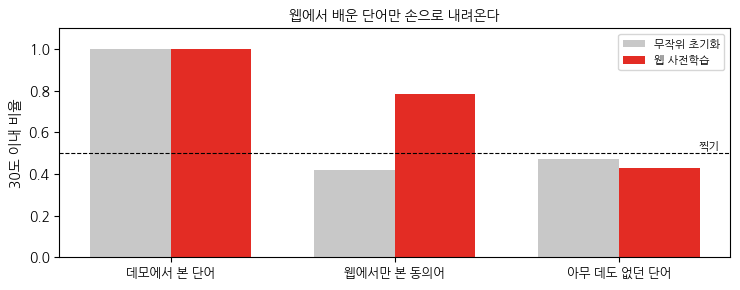

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3))
xs = np.arange(len(SPLITS)); w = .36
ax.bar(xs - w/2, [res["무작위 초기화"][i][1] for i in range(3)], w, color=GREY, label="무작위 초기화")
ax.bar(xs + w/2, [res["웹 사전학습"][i][1] for i in range(3)], w, color=RED_C, label="웹 사전학습")
ax.axhline(.5, color="k", ls="--", lw=.8)
ax.text(2.45, .52, "찍기", fontsize=8, ha="right")
ax.set_xticks(xs); ax.set_xticklabels([s for s, _ in SPLITS], fontsize=9)
ax.set_ylabel("30도 이내 비율"); ax.set_ylim(0, 1.1)
ax.legend(fontsize=8); ax.set_title("웹에서 배운 단어만 손으로 내려온다", fontsize=10)
plt.tight_layout(); plt.show()

## 5. co-fine-tuning 은 언제 필요한가

RT-2 의 실제 레시피에는 한 가지가 더 있다. 로봇 데이터로 파인튜닝할 때 **웹 데이터를 계속 섞는다.** co-fine-tuning 이라 부르고, 이유는 파국적 망각을 막기 위해서다. 로봇 데이터만으로 오래 학습하면 웹에서 얻은 표현이 덮여 버린다는 것이다.

이 노트북에서도 재 봤다. 결과는 교과서와 다르다.

In [8]:
rows = []
for steps in (1200, 5000):
    for co_ft in (False, True):
        m = train_policy(True, steps=steps, co_finetune=co_ft)
        acc = evaluate(m, WEB_ONLY)[1]
        s, d = syn_gap(m.emb.weight.detach())
        rows.append((steps, co_ft, acc, s - d))

print(f"{'로봇 학습':>10}{'co-finetune':>13}{'동의어 정확도':>15}{'임베딩 간격':>14}")
print("-" * 54)
for st, cf, acc, gap in rows:
    print(f"{st:>10}{'예' if cf else '아니오':>12}{acc:>14.0%}{gap:>14.3f}")
print("-" * 54)
print("5000스텝을 돌려도 임베딩 간격이 거의 그대로다. 망각이 일어나지 않았다.")

     로봇 학습  co-finetune        동의어 정확도        임베딩 간격
------------------------------------------------------
      1200         아니오           79%         0.389
      1200           예           83%         0.395
      5000         아니오           83%         0.394
      5000           예           86%         0.407
------------------------------------------------------
5000스텝을 돌려도 임베딩 간격이 거의 그대로다. 망각이 일어나지 않았다.



### 다음 장으로

가장 먼저 갈라선 쪽이 OpenVLA 다. 같은 주장을 오픈 웨이트로 재현하면서 규모를 7B 로 낮췄고, 뒤이어 나온 OFT 가 디코딩 방식을 바꿔 처리량을 26배로 끌어올렸다. 9장에서 그 세 가지 처방을 하나씩 뜯어 본다.